Today is a **review and debrief day** -- no new material. We will revisit Quiz 1,
then work through examples that connect the first two weeks.

> By the end of today you should be able to complete all of Homework 2.

# Quiz 1 debrief: what was in scope

* `np.array` and `shape`
* 1D and 2D indexing/slicing (no boolean indexing yet)
* elementwise arithmetic and broadcasting
* `np.mean()`, `np.median()`, `np.var()`, `np.std()`
* `np.percentile`
* reading a histogram
* `axis` on a 2D array
* scalar/vector/matrix, and int/float/categorical

Bring questions from the quiz; the examples below revisit every item in this list.

## [Check your understanding] Quick review: dimensionality and type

* Is atomic number a scalar or a vector -- `int` or `float`?
* Is alloy phase type or dimensionality, and which category?
* Your own examples for each.

# Worked example 1: array creation, indexing, arithmetic

Vickers hardness (HV), 10 aluminum coupons:

In [1]:
import numpy as np

hardness = np.array([112.4, 108.9, 115.2, 110.1, 109.6,
                      117.8, 111.3, 113.0, 108.2, 114.6])
print(hardness)

[112.4 108.9 115.2 110.1 109.6 117.8 111.3 113.  108.2 114.6]


*What shape does this array have?*

In [2]:
print(hardness.shape)

(10,)



**Predict first:** `hardness[:3]`, `hardness[::2]`, `hardness[-1]`?

In [3]:
print(hardness[:3])
print(hardness[::2])
print(hardness[-1])

[112.4 108.9 115.2]
[112.4 115.2 109.6 111.3 108.2]
114.6


Illustrative Vickers→UTS conversion (not physically valid for Al):

$$\text{UTS (MPa)} \approx 3.3 \times \text{HV}$$

In [4]:
uts_estimate = 3.3 * hardness
print(uts_estimate)

[370.92 359.37 380.16 363.33 361.68 388.74 367.29 372.9  357.06 378.18]


One line, ten conversions. Deviation from the mean, same broadcasting trick:

In [5]:
deviation = hardness - np.mean(hardness)
print(deviation)

[ 0.29 -3.21  3.09 -2.01 -2.51  5.69 -0.81  0.89 -3.91  2.49]


Above-mean → positive, below → negative, roughly balances. Next: why mean deviation isn't a spread measure.

# Worked example 2: descriptive statistics and the one histogram

Percent porosity, 10 sintered ceramic coupons:

In [6]:
porosity = np.array([4.1, 3.8, 5.6, 4.4, 3.9,
                      4.7, 12.1, 4.0, 4.5, 3.6])
print(porosity)

[ 4.1  3.8  5.6  4.4  3.9  4.7 12.1  4.   4.5  3.6]


Four Lecture 4 statistics, both datasets side by side:

In [7]:
print('Hardness:')
print(f'  mean:   {np.mean(hardness):.2f}')
print(f'  median: {np.median(hardness):.2f}')
print(f'  var:    {np.var(hardness):.2f}')
print(f'  std:    {np.std(hardness):.2f}')

print('Porosity:')
print(f'  mean:   {np.mean(porosity):.2f}')
print(f'  median: {np.median(porosity):.2f}')
print(f'  var:    {np.var(porosity):.2f}')
print(f'  std:    {np.std(porosity):.2f}')

Hardness:
  mean:   112.11
  median: 111.85
  var:    8.56
  std:    2.93
Porosity:
  mean:   5.07
  median: 4.25
  var:    5.78
  std:    2.41


*Which measurement is more consistent, and how do you know?*

Porosity mean vs. median: one coupon (12.1%) drags the mean up, barely moves the median -- outlier symptom.

Percentiles, same as Lecture 5:

In [8]:
q25, q50, q75 = np.percentile(porosity, [25, 50, 75])
print(f'25th percentile: {q25}')
print(f'50th percentile (median): {q50}')
print(f'75th percentile: {q75}')
print(f'IQR: {q75 - q25}')

25th percentile: 3.925
50th percentile (median): 4.25
75th percentile: 4.65
IQR: 0.7250000000000005


One plot type so far — histogram, as in Lecture 5 (plotting code hidden; focus on the shape):

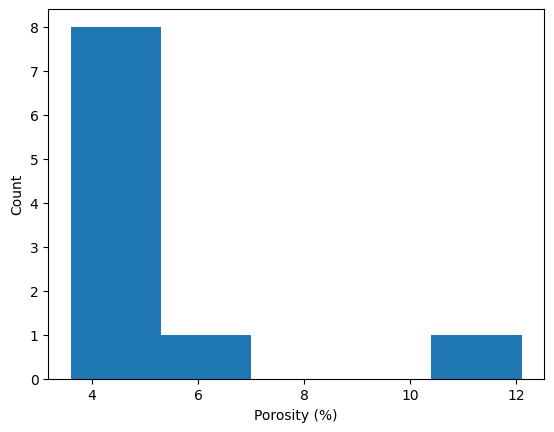

In [9]:
#@title Visualization: porosity histogram (click ▶ to run) { display-mode: "form" }
import matplotlib.pyplot as plt

plt.hist(porosity, bins=5)
plt.xlabel('Porosity (%)')
plt.ylabel('Count')
plt.show()

Point at the bar with the outlier coupon -- ties back to the mean/median gap above.

# Putting it together: a 2D array and `axis`

6 specimens × 4 trials each. Rows = specimens, columns = trials -- same layout a spreadsheet or `DataFrame` uses.

In [10]:
#@title Generate synthetic trial data (click ▶ to run — data generation code, not a learning objective) { display-mode: "form" }
rng = np.random.default_rng(seed=219)

true_means = np.array([[110], [115], [108], [120], [112], [117]])   # nested [[...]] makes a 2D column — one inner list per row
trials = true_means + rng.normal(0, 1.5, size=(6, 4))   # (6, 4) is a tuple specifying rows × columns
trials = np.round(trials, 1)   # np.round rounds to the given number of decimal places
print(trials)

[[108.  109.  111.3 114.7]
 [113.2 114.4 113.9 116.1]
 [110.  108.1 105.9 107.6]
 [118.6 121.8 118.6 119. ]
 [111.7 113.3 111.7 113.4]
 [115.8 119.8 116.4 117.1]]


`true_means` shape `(6, 1)` broadcast across 4 columns -- same rule as before, column vector this time.

In [11]:
print(true_means.shape)
print(trials.shape)

(6, 1)
(6, 4)


2D indexing:

In [12]:
print(trials[0])      # shorthand for trials[0, :] — the whole first row
print(trials[:, 0])    # the whole first column (trial 0, all 6 specimens)
print(trials[2, 1])    # specimen 2, trial 1

[108.  109.  111.3 114.7]
[108.  113.2 110.  118.6 111.7 115.8]
108.1


Two questions:
* consistency *per specimen* → collapse columns, one number per row
* consistency *per trial* → collapse rows, one number per column

`axis=1` collapses columns, `axis=0` collapses rows.

In [13]:
per_specimen_mean = np.mean(trials, axis=1)
per_specimen_std = np.std(trials, axis=1)
print('Per-specimen mean:', per_specimen_mean)
print('Per-specimen std: ', per_specimen_std)
print('shape:', per_specimen_mean.shape)

Per-specimen mean: [110.75  114.4   107.9   119.5   112.525 117.275]
Per-specimen std:  [2.57536405 1.07004673 1.46116392 1.33790882 0.82575723 1.52868407]
shape: (6,)


In [14]:
per_trial_mean = np.mean(trials, axis=0)
print('Per-trial mean:', per_trial_mean)
print('shape:', per_trial_mean.shape)

Per-trial mean: [112.88333333 114.4        112.96666667 114.65      ]
shape: (4,)


`axis=1` → 6 numbers (rows). `axis=0` → 4 numbers (columns). Unsure which? Check the output shape.

## [Check your understanding]
From `per_specimen_std` above, before running the cell:
* Most consistent specimen (smallest std)?
* Least consistent (largest std)?

In [15]:
print('Per-specimen std:', per_specimen_std)
print('Smallest std:', np.min(per_specimen_std))
print('Largest std:', np.max(per_specimen_std))

Per-specimen std: [2.57536405 1.07004673 1.46116392 1.33790882 0.82575723 1.52868407]
Smallest std: 0.8257572282456866
Largest std: 2.5753640519351833


# Wrap-up

Use the quiz debrief and these examples to identify one topic to practice before Homework 2.